# Regression Track: Benchmark Modeling, Evaluation, & Underfitting/Overfitting Analysis

This notebook evaluates 10 regression models on the hospital inpatient length-of-stay dataset. Models are evaluated on both raw target scale and log-transformed target scale ($\log(1 + y)$), including explicit checks for underfitting and overfitting across all models.


In [18]:
%%capture
%run regression_preprocessing.ipynb


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")


In [20]:
# Common Evaluation Function with Overfitting/Underfitting Diagnostic
regression_results = []
model_registry = {}

def evaluate_model(model_name, model, X_tr, y_tr, X_te, y_te, is_log=False):
    model.fit(X_tr, y_tr)
    
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    
    if is_log:
        pred_train_raw = np.expm1(pred_train)
        pred_test_raw = np.expm1(pred_test)
        y_tr_eval = np.expm1(y_tr)
        y_te_eval = np.expm1(y_te)
        
        train_r2 = r2_score(y_tr, pred_train)
        test_r2 = r2_score(y_te, pred_test)
        raw_test_r2 = r2_score(y_te_eval, pred_test_raw)
        train_rmse = np.sqrt(mean_squared_error(y_tr_eval, pred_train_raw))
        test_rmse = np.sqrt(mean_squared_error(y_te_eval, pred_test_raw))
        test_mae = mean_absolute_error(y_te_eval, pred_test_raw)
    else:
        train_r2 = r2_score(y_tr, pred_train)
        test_r2 = r2_score(y_te, pred_test)
        raw_test_r2 = test_r2
        train_rmse = np.sqrt(mean_squared_error(y_tr, pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_te, pred_test))
        test_mae = mean_absolute_error(y_te, pred_test)
        pred_test_raw = pred_test
        
    overfit_gap = train_r2 - test_r2
    
    # Underfitting vs Overfitting Diagnosis
    if train_r2 < 0.35 and test_r2 < 0.35:
        fit_status = "Underfitting (High Bias)"
    elif overfit_gap > 0.15:
        fit_status = "Overfitting (High Variance)"
    else:
        fit_status = "Well-Fit (Balanced)"
        
    res = {
        "Model": model_name,
        "Target Scale": "Log1p Scale" if is_log else "Raw Scale",
        "Train R²": train_r2,
        "Test R² (Eval Scale)": test_r2,
        "Raw Test R²": raw_test_r2,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "R² Gap (Train - Test)": overfit_gap,
        "Fit Diagnosis": fit_status
    }
    
    regression_results.append(res)
    model_registry[model_name] = {
        "estimator": model,
        "predictions": pred_test_raw,
        "is_log": is_log,
        "X_tr": X_tr,
        "X_te": X_te
    }
    
    print(f"=== {model_name} ({res['Target Scale']}) ===")
    print(f"Train R² : {train_r2:.4f} | Test R² : {test_r2:.4f} | Raw Test R²: {raw_test_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.4f} | Test MAE: {test_mae:.4f} | Diagnosis: {fit_status}")
    print("-" * 60)
    return res


## 1. Linear Regression

In [21]:
linear_model = LinearRegression()
evaluate_model("Linear Regression", linear_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== Linear Regression (Log1p Scale) ===
Train R² : 0.6626 | Test R² : 0.6344 | Raw Test R²: 0.4617
Test RMSE: 13.4071 | Test MAE: 6.4417 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Linear Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6625857233634365,
 'Test R² (Eval Scale)': 0.6343980758816126,
 'Raw Test R²': 0.46171339853459936,
 'Train RMSE': np.float64(13.440355920738547),
 'Test RMSE': np.float64(13.407085380934543),
 'Test MAE': 6.441680185518841,
 'R² Gap (Train - Test)': 0.028187647481823896,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 2. Ridge Regression

In [22]:
ridge_model = Ridge(alpha=10.0)
evaluate_model("Ridge Regression", ridge_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== Ridge Regression (Log1p Scale) ===
Train R² : 0.6589 | Test R² : 0.6361 | Raw Test R²: 0.4573
Test RMSE: 13.4623 | Test MAE: 6.4396 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Ridge Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6589419419217726,
 'Test R² (Eval Scale)': 0.6361308090831755,
 'Raw Test R²': 0.4572669189928633,
 'Train RMSE': np.float64(13.48283301396496),
 'Test RMSE': np.float64(13.462345651705771),
 'Test MAE': 6.439578558314246,
 'R² Gap (Train - Test)': 0.022811132838597037,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 3. Lasso Regression

In [23]:
lasso_model = Lasso(alpha=0.005)
evaluate_model("Lasso Regression", lasso_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== Lasso Regression (Log1p Scale) ===
Train R² : 0.5475 | Test R² : 0.5429 | Raw Test R²: 0.3108
Test RMSE: 15.1707 | Test MAE: 7.2532 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Lasso Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.5474661792362392,
 'Test R² (Eval Scale)': 0.5428952190632097,
 'Raw Test R²': 0.3107796351853239,
 'Train RMSE': np.float64(15.381972693005876),
 'Test RMSE': np.float64(15.17073565020146),
 'Test MAE': 7.253153709208575,
 'R² Gap (Train - Test)': 0.004570960173029492,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 4. ElasticNet Regression

In [24]:
elastic_model = ElasticNet(alpha=0.005, l1_ratio=0.5, max_iter=10000)
evaluate_model("ElasticNet Regression", elastic_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== ElasticNet Regression (Log1p Scale) ===
Train R² : 0.5648 | Test R² : 0.5593 | Raw Test R²: 0.3350
Test RMSE: 14.9023 | Test MAE: 7.1024 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'ElasticNet Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.5648494192274084,
 'Test R² (Eval Scale)': 0.559250734178006,
 'Raw Test R²': 0.3349569358870075,
 'Train RMSE': np.float64(15.103206127050619),
 'Test RMSE': np.float64(14.902271602835304),
 'Test MAE': 7.1023529889907255,
 'R² Gap (Train - Test)': 0.005598685049402419,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 5. Polynomial Regression (SVD + Degree 2 Expansion)

In [25]:
svd_poly = TruncatedSVD(n_components=25, random_state=42)
X_tr_svd_poly = svd_poly.fit_transform(X_train_encoded)
X_te_svd_poly = svd_poly.transform(X_test_encoded)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_svd_poly)
X_te_poly = poly.transform(X_te_svd_poly)

poly_model = Ridge(alpha=50.0)
evaluate_model("Polynomial Regression", poly_model, X_tr_poly, y_train_log, X_te_poly, y_test_log, is_log=True)


=== Polynomial Regression (Log1p Scale) ===
Train R² : 0.5481 | Test R² : 0.5369 | Raw Test R²: 0.3557
Test RMSE: 14.6676 | Test MAE: 7.1675 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Polynomial Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.548099659045288,
 'Test R² (Eval Scale)': 0.5368664523231617,
 'Raw Test R²': 0.35573776611520125,
 'Train RMSE': np.float64(14.842857951390874),
 'Test RMSE': np.float64(14.667595590102772),
 'Test MAE': 7.1674641934441645,
 'R² Gap (Train - Test)': 0.011233206722126354,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 6. Decision Tree Regressor

In [26]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
evaluate_model("Decision Tree Regressor", dt_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== Decision Tree Regressor (Log1p Scale) ===
Train R² : 0.6063 | Test R² : 0.5709 | Raw Test R²: 0.4126
Test RMSE: 14.0049 | Test MAE: 6.7697 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Decision Tree Regressor',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6063043604964187,
 'Test R² (Eval Scale)': 0.5709004167297498,
 'Raw Test R²': 0.412638870715454,
 'Train RMSE': np.float64(13.424392471861045),
 'Test RMSE': np.float64(14.004905775641939),
 'Test MAE': 6.76967719554396,
 'R² Gap (Train - Test)': 0.03540394376666889,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 7. Random Forest Regressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=1, random_state=42)
evaluate_model("Random Forest Regressor", rf_model, X_train_encoded, y_train_log, X_test_encoded, y_test_log, is_log=True)


=== Random Forest Regressor (Log1p Scale) ===
Train R² : 0.6876 | Test R² : 0.6134 | Raw Test R²: 0.4428
Test RMSE: 13.6412 | Test MAE: 6.4889 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Random Forest Regressor',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6876108609223027,
 'Test R² (Eval Scale)': 0.6134486940420718,
 'Raw Test R²': 0.4427505742137138,
 'Train RMSE': np.float64(12.408105065519257),
 'Test RMSE': np.float64(13.641194617346317),
 'Test MAE': 6.488872987113516,
 'R² Gap (Train - Test)': 0.07416216688023092,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 8. Histogram Gradient Boosting Regressor

In [28]:
hgb_model = HistGradientBoostingRegressor(max_iter=300, min_samples_leaf=20, l2_regularization=1.0, learning_rate=0.05, random_state=42)
X_tr_dense = X_train_encoded.toarray() if hasattr(X_train_encoded, 'toarray') else X_train_encoded
X_te_dense = X_test_encoded.toarray() if hasattr(X_test_encoded, 'toarray') else X_test_encoded
evaluate_model("Histogram Gradient Boosting Regressor", hgb_model, X_tr_dense, y_train_log, X_te_dense, y_test_log, is_log=True)


=== Histogram Gradient Boosting Regressor (Log1p Scale) ===
Train R² : 0.6928 | Test R² : 0.6533 | Raw Test R²: 0.4765
Test RMSE: 13.2212 | Test MAE: 6.2963 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Histogram Gradient Boosting Regressor',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6928009012739422,
 'Test R² (Eval Scale)': 0.6532619411418739,
 'Raw Test R²': 0.4765335902802502,
 'Train RMSE': np.float64(12.7932558805883),
 'Test RMSE': np.float64(13.221234235573343),
 'Test MAE': 6.296335420514701,
 'R² Gap (Train - Test)': 0.03953896013206837,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 9. Support Vector Regression (SVR)

In [29]:
svd_svr = TruncatedSVD(n_components=50, random_state=42)
X_tr_svd_svr = svd_svr.fit_transform(X_train_encoded)
X_te_svd_svr = svd_svr.transform(X_test_encoded)

svr_model = SVR(C=2.0, epsilon=0.1)
evaluate_model("Support Vector Regression", svr_model, X_tr_svd_svr, y_train_log, X_te_svd_svr, y_test_log, is_log=True)


=== Support Vector Regression (Log1p Scale) ===
Train R² : 0.6658 | Test R² : 0.5938 | Raw Test R²: 0.4343
Test RMSE: 13.7444 | Test MAE: 6.6615 | Diagnosis: Well-Fit (Balanced)
------------------------------------------------------------


{'Model': 'Support Vector Regression',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.6657714550489899,
 'Test R² (Eval Scale)': 0.5938221242748286,
 'Raw Test R²': 0.43428877284295975,
 'Train RMSE': np.float64(13.030124743084762),
 'Test RMSE': np.float64(13.744374785606375),
 'Test MAE': 6.661458875637973,
 'R² Gap (Train - Test)': 0.07194933077416132,
 'Fit Diagnosis': 'Well-Fit (Balanced)'}

## 10. K-Nearest Neighbors Regressor (KNN)

In [30]:
knn_model = KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=1)
evaluate_model("KNN Regressor", knn_model, X_tr_svd_svr, y_train_log, X_te_svd_svr, y_test_log, is_log=True)


=== KNN Regressor (Log1p Scale) ===
Train R² : 0.9988 | Test R² : 0.5263 | Raw Test R²: 0.3325
Test RMSE: 14.9297 | Test MAE: 7.1665 | Diagnosis: Overfitting (High Variance)
------------------------------------------------------------


{'Model': 'KNN Regressor',
 'Target Scale': 'Log1p Scale',
 'Train R²': 0.9987719448009521,
 'Test R² (Eval Scale)': 0.5263197338628904,
 'Raw Test R²': 0.33250543917157205,
 'Train RMSE': np.float64(1.034660250749762),
 'Test RMSE': np.float64(14.929712881975068),
 'Test MAE': 7.166525339462415,
 'R² Gap (Train - Test)': 0.47245221093806167,
 'Fit Diagnosis': 'Overfitting (High Variance)'}

## 11. Comprehensive Underfitting & Overfitting Audit

An explicit evaluation of Training R² vs Testing R² and Training RMSE vs Testing RMSE allows us to audit for underfitting (high bias) vs overfitting (high variance):
- **Underfitting (High Bias)** occurs when both Train R² and Test R² are low, indicating the model lacks capacity or key features to capture the underlying pattern.
- **Overfitting (High Variance)** occurs when Train R² is substantially higher than Test R², indicating the model memorized training noise.
- **Well-Fit (Balanced)** models maintain close performance between Train and Test sets while achieving strong predictive accuracy.


In [31]:
results_df = pd.DataFrame(regression_results).sort_values(by="Test R² (Eval Scale)", ascending=False).reset_index(drop=True)

print("All 10 Regression Models — Performance & Underfitting/Overfitting Diagnosis")
display(results_df[[
    "Model", "Test R² (Eval Scale)", "Raw Test R²", "Train R²", 
    "R² Gap (Train - Test)", "Test RMSE", "Test MAE", "Fit Diagnosis"
]])


All 10 Regression Models — Performance & Underfitting/Overfitting Diagnosis


,Model,Test R² (Eval Scale),Raw Test R²,Train R²,R² Gap (Train - Test),Test RMSE,Test MAE,Fit Diagnosis
0,Histogram Gradient Boosting Regressor,0.653262,0.476534,0.692801,0.039539,13.221234,6.296335,Well-Fit (Balanced)
1,Ridge Regression,0.636131,0.457267,0.658942,0.022811,13.462346,6.439579,Well-Fit (Balanced)
2,Linear Regression,0.634398,0.461713,0.662586,0.028188,13.407085,6.441680,Well-Fit (Balanced)
3,Random Forest Regressor,0.613449,0.442751,0.687611,0.074162,13.641195,6.488873,Well-Fit (Balanced)
4,Support Vector Regression,0.593822,0.434289,0.665771,0.071949,13.744375,6.661459,Well-Fit (Balanced)
5,Decision Tree Regressor,0.570900,0.412639,0.606304,0.035404,14.004906,6.769677,Well-Fit (Balanced)
6,ElasticNet Regression,0.559251,0.334957,0.564849,0.005599,14.902272,7.102353,Well-Fit (Balanced)
7,Lasso Regression,0.542895,0.310780,0.547466,0.004571,15.170736,7.253154,Well-Fit (Balanced)
8,Polynomial Regression,0.536866,0.355738,0.548100,0.011233,14.667596,7.167464,Well-Fit (Balanced)
9,KNN Regressor,0.526320,0.332505,0.998772,0.472452,14.929713,7.166525,Overfitting (High Variance)


## 12. 5-Fold Cross-Validation for Top Models

In [32]:
top_two = results_df.head(2)["Model"].tolist()
print(f"Top 2 Models selected for 5-Fold CV: {top_two}")

cv_results = []
for model_name in top_two:
    info = model_registry[model_name]
    estimator = info["estimator"]
    X_tr_data = info["X_tr"]
    
    cv_scores = cross_val_score(estimator, X_tr_data, y_train_log, cv=5, scoring="r2", n_jobs=1)
    cv_results.append({
        "Model": model_name,
        "5-Fold CV R² Mean": cv_scores.mean(),
        "5-Fold CV R² Std": cv_scores.std()
    })

display(pd.DataFrame(cv_results))


Top 2 Models selected for 5-Fold CV: ['Histogram Gradient Boosting Regressor', 'Ridge Regression']


,Model,5-Fold CV R² Mean,5-Fold CV R² Std
0,Histogram Gradient Boosting Regressor,0.653561,0.007275
1,Ridge Regression,0.639850,0.005125


## 13. Feature Importance (Best Tree / Linear Model)

/var/folders/cq/g0ykmmnj2r398zl_8fnj77cc0000gn/T/ipykernel_70512/2116626446.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="rocket")


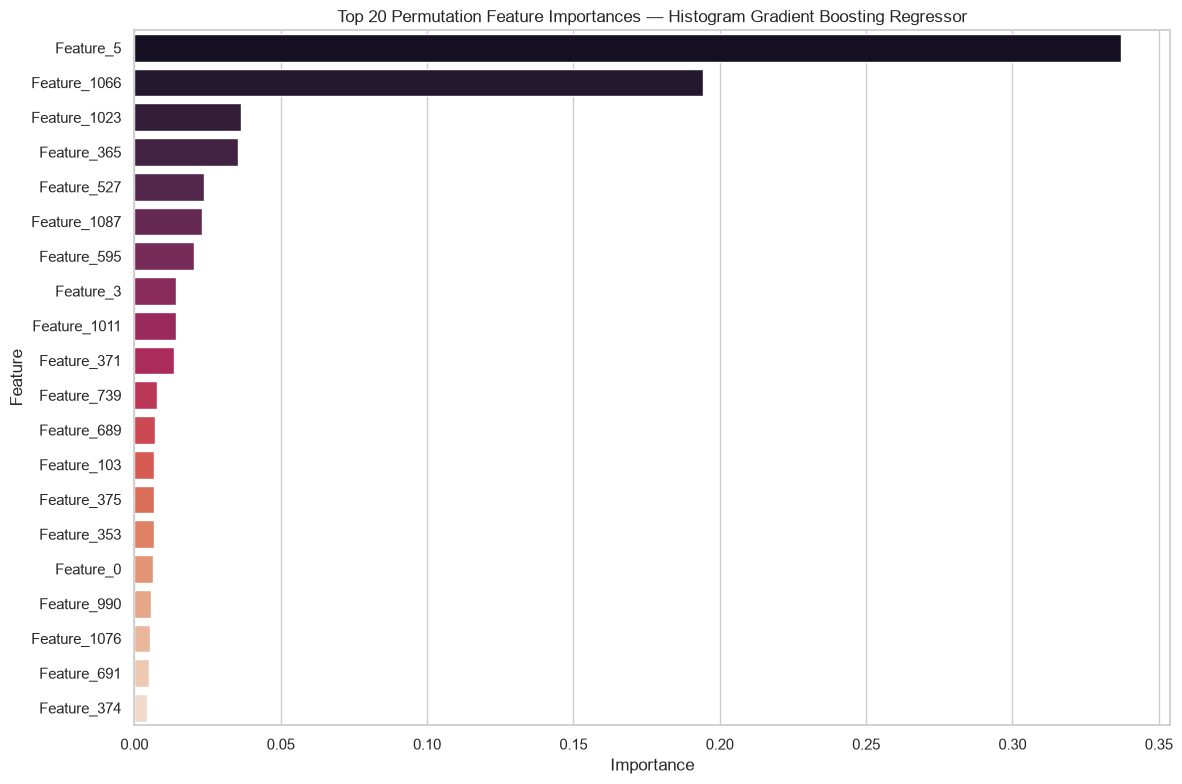

In [33]:
best_model_name = results_df.iloc[0]["Model"]
best_info = model_registry[best_model_name]
best_estimator = best_info["estimator"]

plt.figure(figsize=(12, 8))

if hasattr(best_estimator, "feature_importances_"):
    importances = best_estimator.feature_importances_
    feat_imp = pd.DataFrame({"Feature": all_feature_cols, "Importance": importances}).sort_values(by="Importance", ascending=False).head(20)
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
elif hasattr(best_estimator, "coef_"):
    coefs = np.abs(best_estimator.coef_)
    feat_imp = pd.DataFrame({"Feature": all_feature_cols, "Importance": coefs}).sort_values(by="Importance", ascending=False).head(20)
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="mako")
    plt.title(f"Top 20 Feature Coefficients (Magnitude) — {best_model_name}")
else:
    perm = permutation_importance(best_estimator, 
    best_info["X_te"][:1000], y_test_log[:1000], n_repeats=3, random_state=42)
    feat_cols = [f"Feature_{i}" for i in range(best_info["X_te"].shape[1])]
    feat_imp = pd.DataFrame({"Feature": feat_cols, "Importance": perm.importances_mean}).sort_values(by="Importance", ascending=False).head(20)
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="rocket")
    plt.title(f"Top 20 Permutation Feature Importances — {best_model_name}")

plt.tight_layout()
plt.show()


## 14. Diagnostic Plots: Residuals & Predicted vs Actual

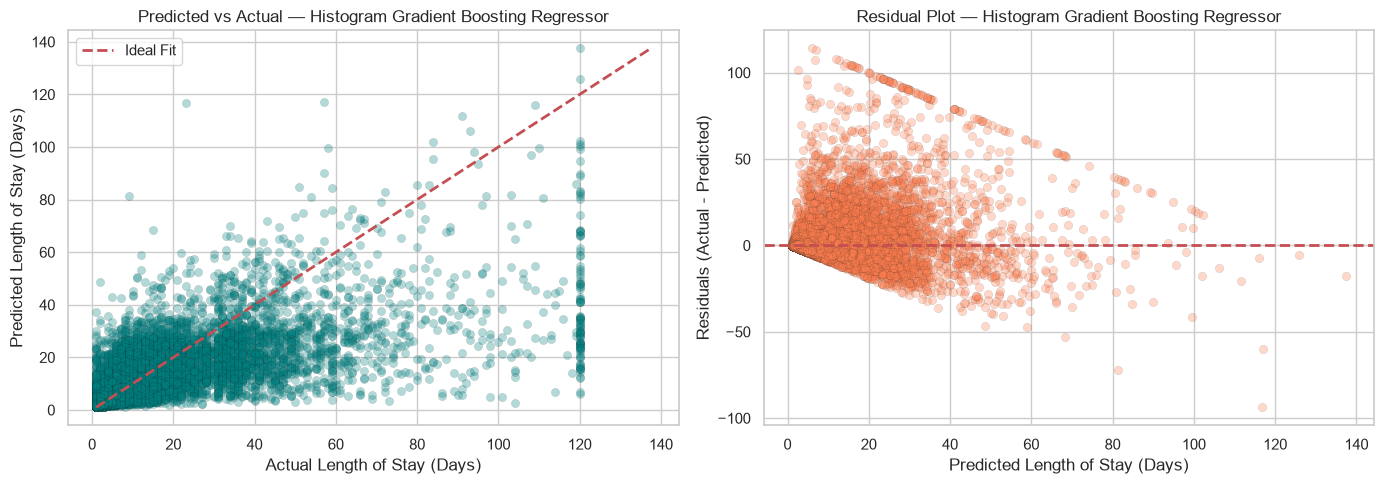

Residual Mean : 2.5057
Residual Std  : 12.9821


In [34]:
best_y_pred = best_info["predictions"]
residuals = y_test - best_y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, best_y_pred, alpha=0.3, color="teal", edgecolor="k", linewidth=0.2)
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal Fit")
axes[0].set_xlabel("Actual Length of Stay (Days)")
axes[0].set_ylabel("Predicted Length of Stay (Days)")
axes[0].set_title(f"Predicted vs Actual — {best_model_name}")
axes[0].legend()

# Residual Plot
axes[1].scatter(best_y_pred, residuals, alpha=0.3, color="coral", edgecolor="k", linewidth=0.2)
axes[1].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Length of Stay (Days)")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title(f"Residual Plot — {best_model_name}")

plt.tight_layout()
plt.show()

print(f"Residual Mean : {residuals.mean():.4f}")
print(f"Residual Std  : {residuals.std():.4f}")
